## Preprocess Data

Clean and preprocess the dataset. This will involve handling categorical variables (e.g., using one-hot encoding), checking for missing values, and splitting the data into features (X) and target (y) for model training. The target variable will be the 'y' column, indicating whether a customer subscribed to a term deposit.


In [ ]:
print("Missing values in df_bank:")
print(df_bank.isnull().sum())

Missing values in df_bank:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
import numpy as np

categorical_cols = df_bank.select_dtypes(include=['object']).columns
print("Categorical columns before processing 'y':", list(categorical_cols))

df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})
print("Converted 'y' column to numerical:")
print(df_bank['y'].value_counts())

y = df_bank['y']

X = df_bank.drop('y', axis=1)

categorical_cols_X = X.select_dtypes(include=['object']).columns
print("Categorical columns in X for one-hot encoding:", list(categorical_cols_X))

X = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True, dtype=int)

print("Shape of X after one-hot encoding:", X.shape)
print("First 5 rows of X after preprocessing:")
display(X.head())
print("First 5 rows of y:")
display(y.head())

Categorical columns before processing 'y': ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Converted 'y' column to numerical:
y
0    36548
1     4640
Name: count, dtype: int64
Categorical columns in X for one-hot encoding: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Shape of X after one-hot encoding: (41188, 53)
First 5 rows of X after preprocessing:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0


First 5 rows of y:


,y
0,0
1,0
2,0
3,0
4,0


## Split Data into Training and Testing Sets

Divide the preprocessed dataset into training and testing sets to evaluate the model's performance on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (28831, 53)
Shape of X_test: (12357, 53)
Shape of y_train: (28831,)
Shape of y_test: (12357,)


## Train Decision Tree Classifier

Initialize and train a Decision Tree Classifier model using the training data.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier(random_state=42)

dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


## Evaluate Model Performance

Evaluate the trained decision tree classifier using appropriate metrics such as accuracy, precision, recall, and F1-score on the test set. Also, generate a confusion matrix.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8899
Precision: 0.5099
Recall: 0.5191
F1-Score: 0.5144

Confusion Matrix:
[[10275   693]
 [  668   721]]


## Visualize Decision Tree


Visualize the trained decision tree to understand the decision rules and feature importance. Ensure the plot has a legend.


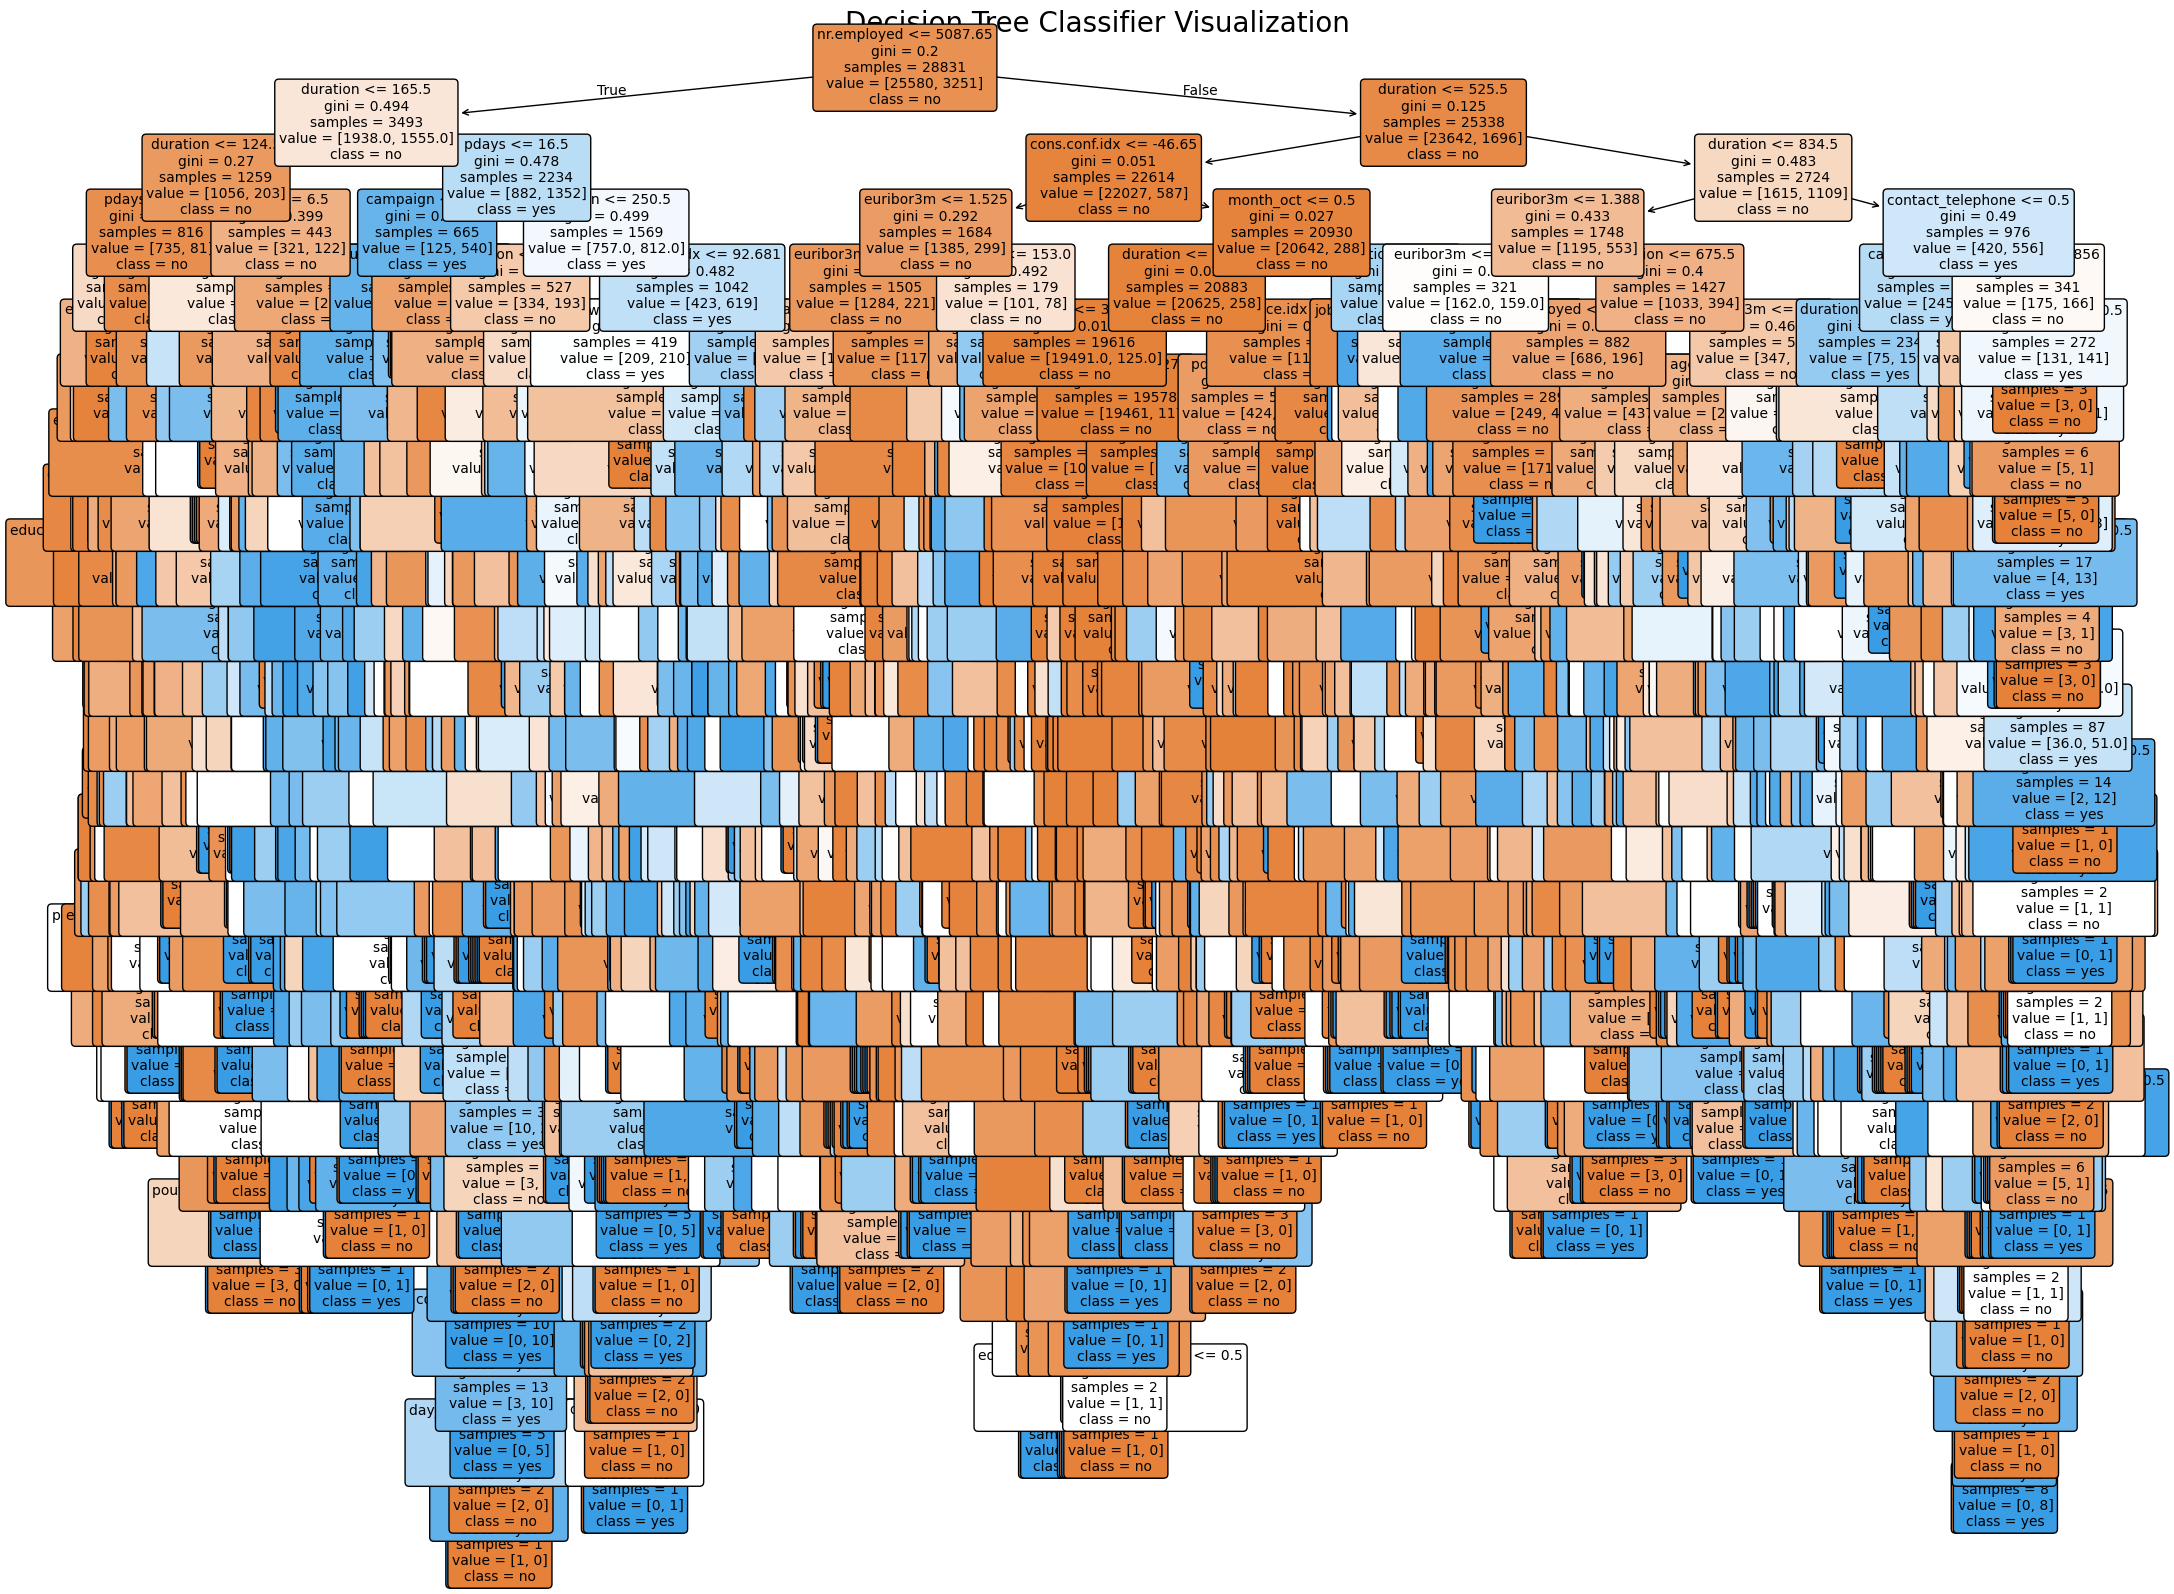

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 20))

plot_tree(dt_classifier,
          feature_names=X.columns,
          class_names=['no', 'yes'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree Classifier Visualization', fontsize=20)
plt.show()


## Final Task

Summarize the decision tree model's performance, key insights from feature importance, and discuss the implications for predicting customer purchases.


## Summary:

### Data Analysis Key Findings
*   The Bank Marketing dataset, comprising 41188 entries and 21 columns, was successfully loaded after an initial file path correction.
*   No missing values were present in the dataset.
*   The target variable 'y' (customer subscription) was highly imbalanced, with 36,548 'no' subscriptions (88.73%) and 4,640 'yes' subscriptions (11.27%).
*   Categorical features were one-hot encoded, transforming the feature set `X` into 53 numerical columns.
*   The dataset was split into training (28831 samples) and testing (12357 samples) sets.
*   The trained Decision Tree Classifier achieved an accuracy of 88.99% on the test set.
*   For the positive class ('yes' for customer purchase), the model yielded a precision of 50.99%, recall of 51.91%, and an F1-score of 51.44%.
*   The confusion matrix indicated 10275 True Negatives, 693 False Positives, 668 False Negatives, and 721 True Positives.
*   A visualization of the decision tree was successfully generated, showcasing the decision rules and implicitly highlighting influential features.
